In [1]:
from scipy.sparse import csr_matrix,issparse
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter
from scipy.sparse import csc_matrix
import anndata as ad
import matplotlib.pyplot as plt
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri, pandas2ri, default_converter, r
from rpy2.robjects.conversion import localconverter
import rpy2.robjects.packages as rpackages
import os
os.makedirs("../results/qc",exist_ok=True)
os.makedirs("../figures/qc",exist_ok=True)
os.makedirs("../workflows",exist_ok=True)

# Suppress verbose logging from Scanpy
sc.settings.verbosity = 0

In [2]:
samples = {
    "adata_fat": r"D:\Desktop\--main\data_interim\Fat_checked.h5ad",
    "adata_spleen_marrow": r"D:\Desktop\--main\data_interim\spleen_marrow_checked.h5ad",
    "adata_heart_and_aorta": r"D:\Desktop\--main\data_interim\Heart_and_Aorta_checked.h5ad",
    "adata_kidney": r"D:\Desktop\--main\data_interim\Kidney_checked.h5ad",
    "adata_liver": r"D:\Desktop\--main\data_interim\Liver_checked.h5ad",
    "adata_lung": r"D:\Desktop\--main\data_interim\Lung_checked.h5ad",
}
adatas = {}
for sample_id, path in samples.items():
    sample_adata = sc.read_h5ad(path)       
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata_raw = adata.copy()

sample
adata_spleen_marrow      75938
adata_lung               24540
adata_kidney             21647
adata_heart_and_aorta     8613
adata_liver               7294
adata_fat                 6777
Name: count, dtype: int64


In [10]:
# 保留原始counts
adata.layers["counts"] = adata.X.copy()

In [11]:
adata.var_names_make_unique()

In [12]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = (adata.var_names.str.startswith("mt-")|adata.var_names.str.startswith("Mt-")|adata.var_names.str.startswith("MT-"))
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))

In [13]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, percent_top=[20], log1p=True)

In [9]:
adata = adata_raw

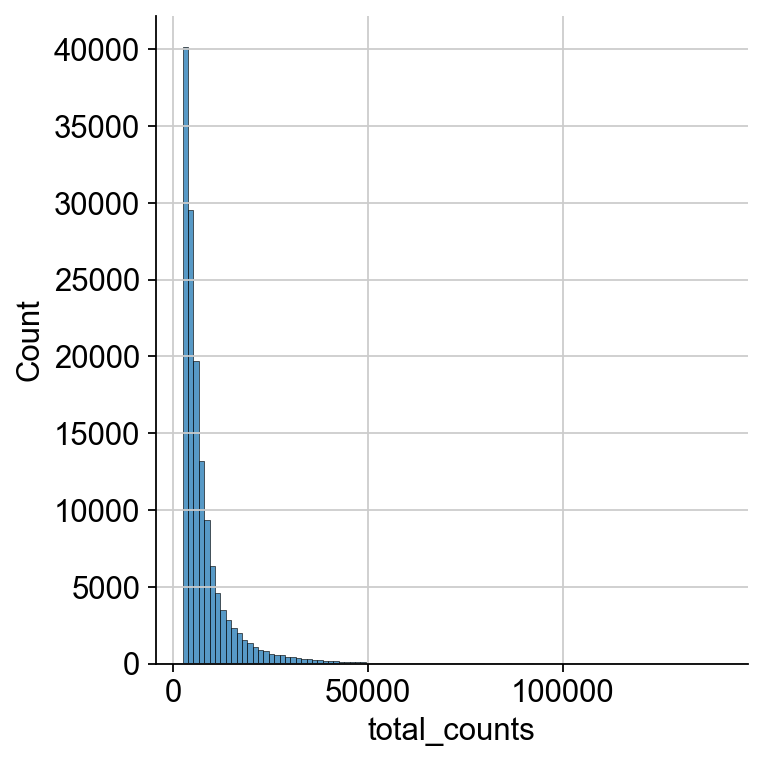

In [49]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)

C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_24228\2465494877.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # 自动调整布局，防止标签被截断


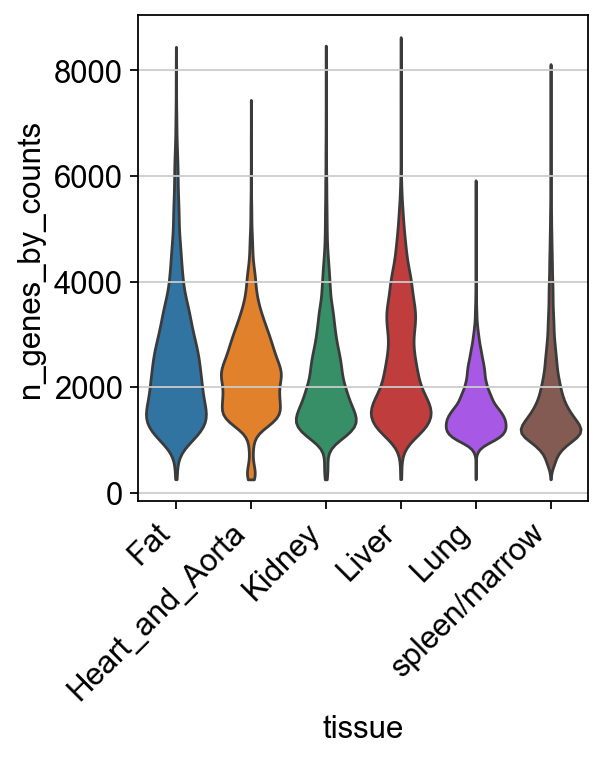

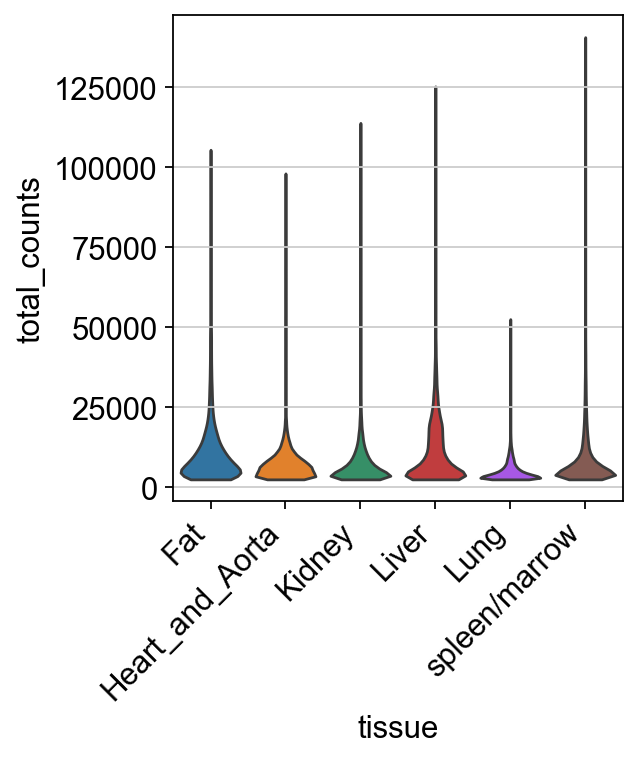

In [50]:
p2 = sc.pl.violin(adata, "n_genes_by_counts", groupby="tissue", stripplot=False, show=False)
p3 = sc.pl.violin(adata, "total_counts", groupby="tissue", stripplot=False, show=False)

# 旋转横坐标标签，避免重叠
for ax in [p2, p3]:
    ax.tick_params(axis='x', rotation=45)
    # 如果旋转后还是挤，可以进一步调整对齐方式
    for label in ax.get_xticklabels():
        label.set_ha('right')

plt.tight_layout()  # 自动调整布局，防止标签被截断
plt.show()

In [14]:
tissue_filters = {
    "Fat": {"min_counts": 200,  "max_counts": 30000, "min_genes": 300, "max_genes": 7000},
    "Heart_and_Aorta": {"min_counts": 200,  "max_counts": 20000, "min_genes": 700, "max_genes": 5500},
    "Kidney": {"min_counts": 200,  "max_counts": 20000, "min_genes": 500, "max_genes": 5500},
    "Liver": {"min_counts": 200,  "max_counts": 35000, "min_genes":500, "max_genes": 6000},
    "Lung":  {"min_counts": 200,  "max_counts": 17000, "min_genes": 500, "max_genes": 3500},
    "spleen/marrow": {"min_counts": 200,  "max_counts": 30000, "min_genes": 200, "max_genes": 5500},
}

filtered_adatas = []
for tissue, params in tissue_filters.items():
    sub = adata[adata.obs["tissue"] == tissue].copy()
    print(f"\n=== {tissue} ===")
    print(f"  过滤前: {sub.n_obs} cells")
    
    # ✅ 改动点：逐个参数依次过滤，避免 ValueError
    for param_name, value in params.items():
        sc.pp.filter_cells(sub, **{param_name: value})
    
    print(f"  过滤后: {sub.n_obs} cells")
    filtered_adatas.append(sub)

# 合并回一个 AnnData
adata_filtered = sc.concat(filtered_adatas, join="outer")
print(f"\n总计过滤后细胞数: {adata_filtered.n_obs}")


=== Fat ===
  过滤前: 6777 cells
  过滤后: 6367 cells

=== Heart_and_Aorta ===
  过滤前: 8613 cells
  过滤后: 8239 cells

=== Kidney ===
  过滤前: 21647 cells
  过滤后: 20596 cells

=== Liver ===
  过滤前: 7294 cells
  过滤后: 7078 cells

=== Lung ===
  过滤前: 24540 cells
  过滤后: 24319 cells

=== spleen/marrow ===
  过滤前: 75938 cells
  过滤后: 73601 cells

总计过滤后细胞数: 140200


C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_24476\812964899.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # 自动调整布局，防止标签被截断


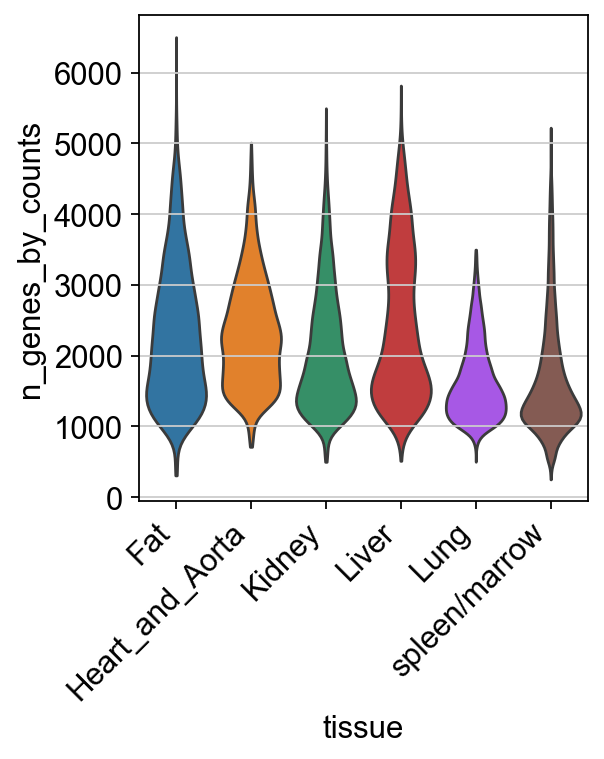

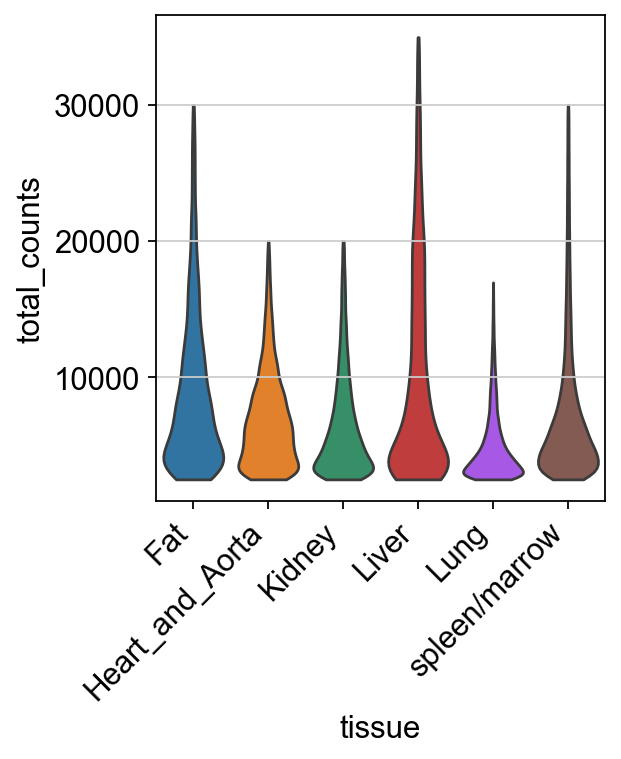

In [15]:
p2 = sc.pl.violin(adata_filtered, "n_genes_by_counts", groupby="tissue", stripplot=False, show=False)
p3 = sc.pl.violin(adata_filtered, "total_counts", groupby="tissue", stripplot=False, show=False)

# 旋转横坐标标签，避免重叠
for ax in [p2, p3]:
    ax.tick_params(axis='x', rotation=45)
    # 如果旋转后还是挤，可以进一步调整对齐方式
    for label in ax.get_xticklabels():
        label.set_ha('right')

plt.tight_layout()  # 自动调整布局，防止标签被截断
plt.show()

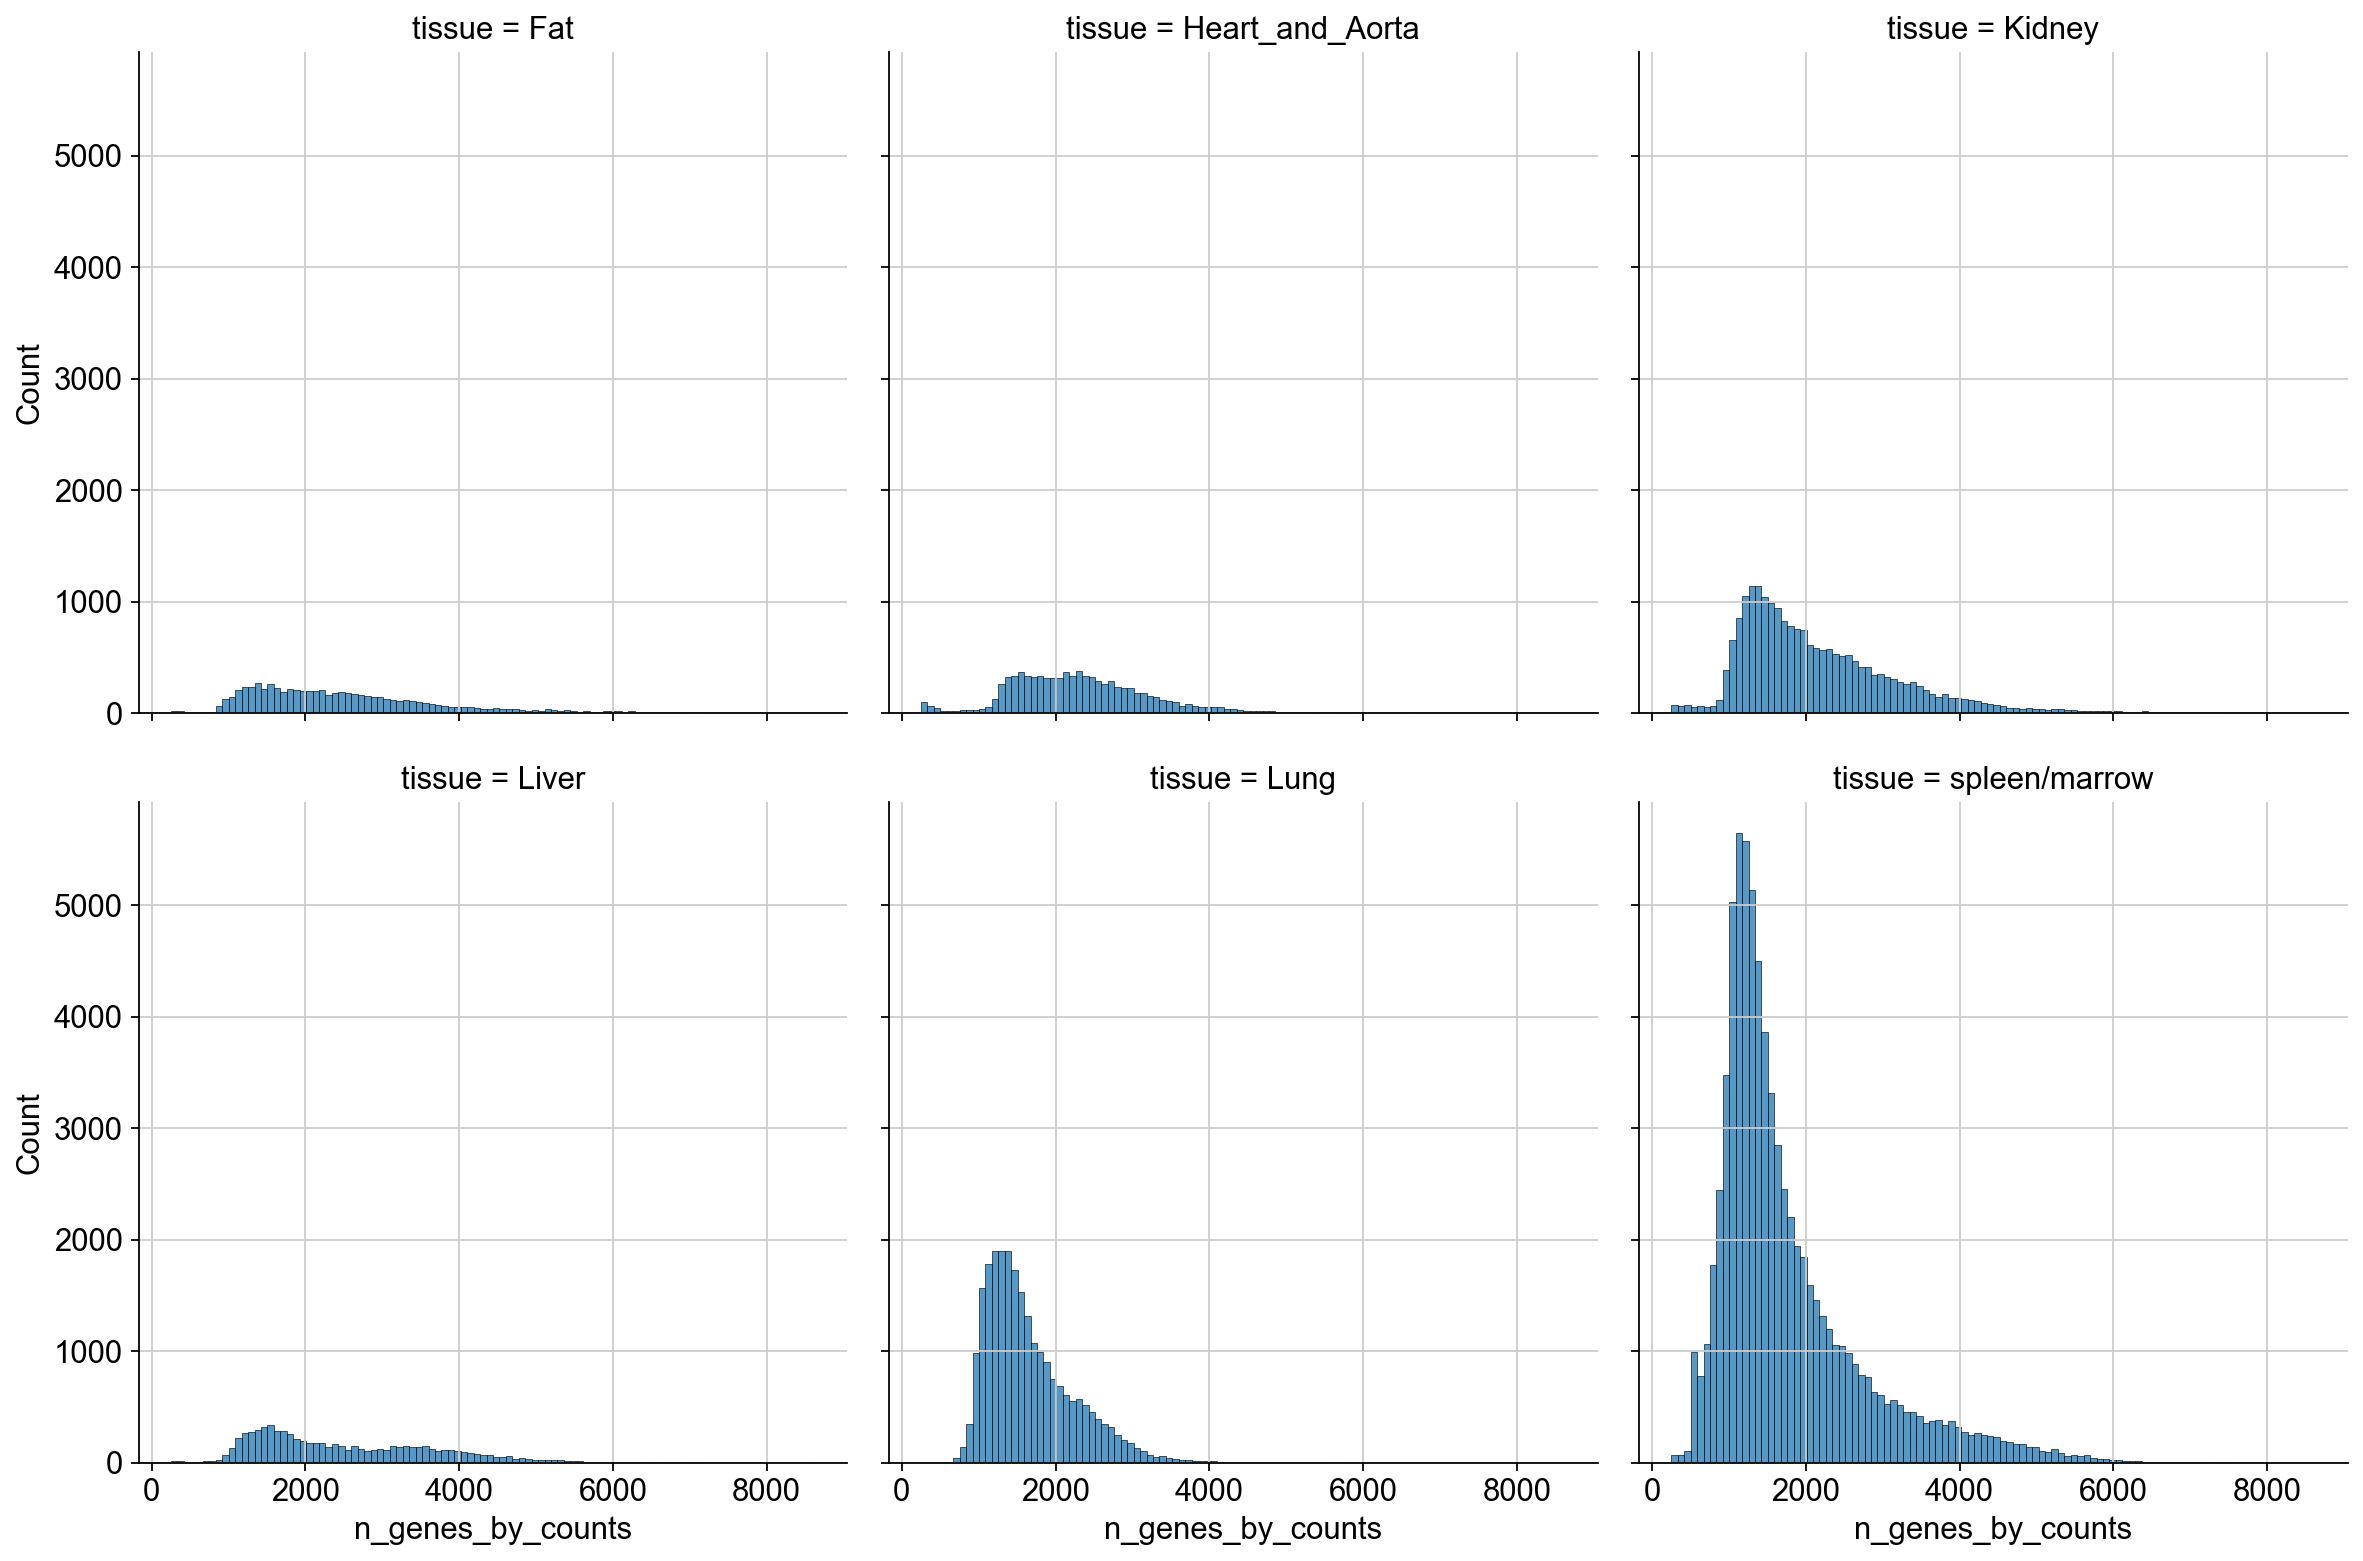

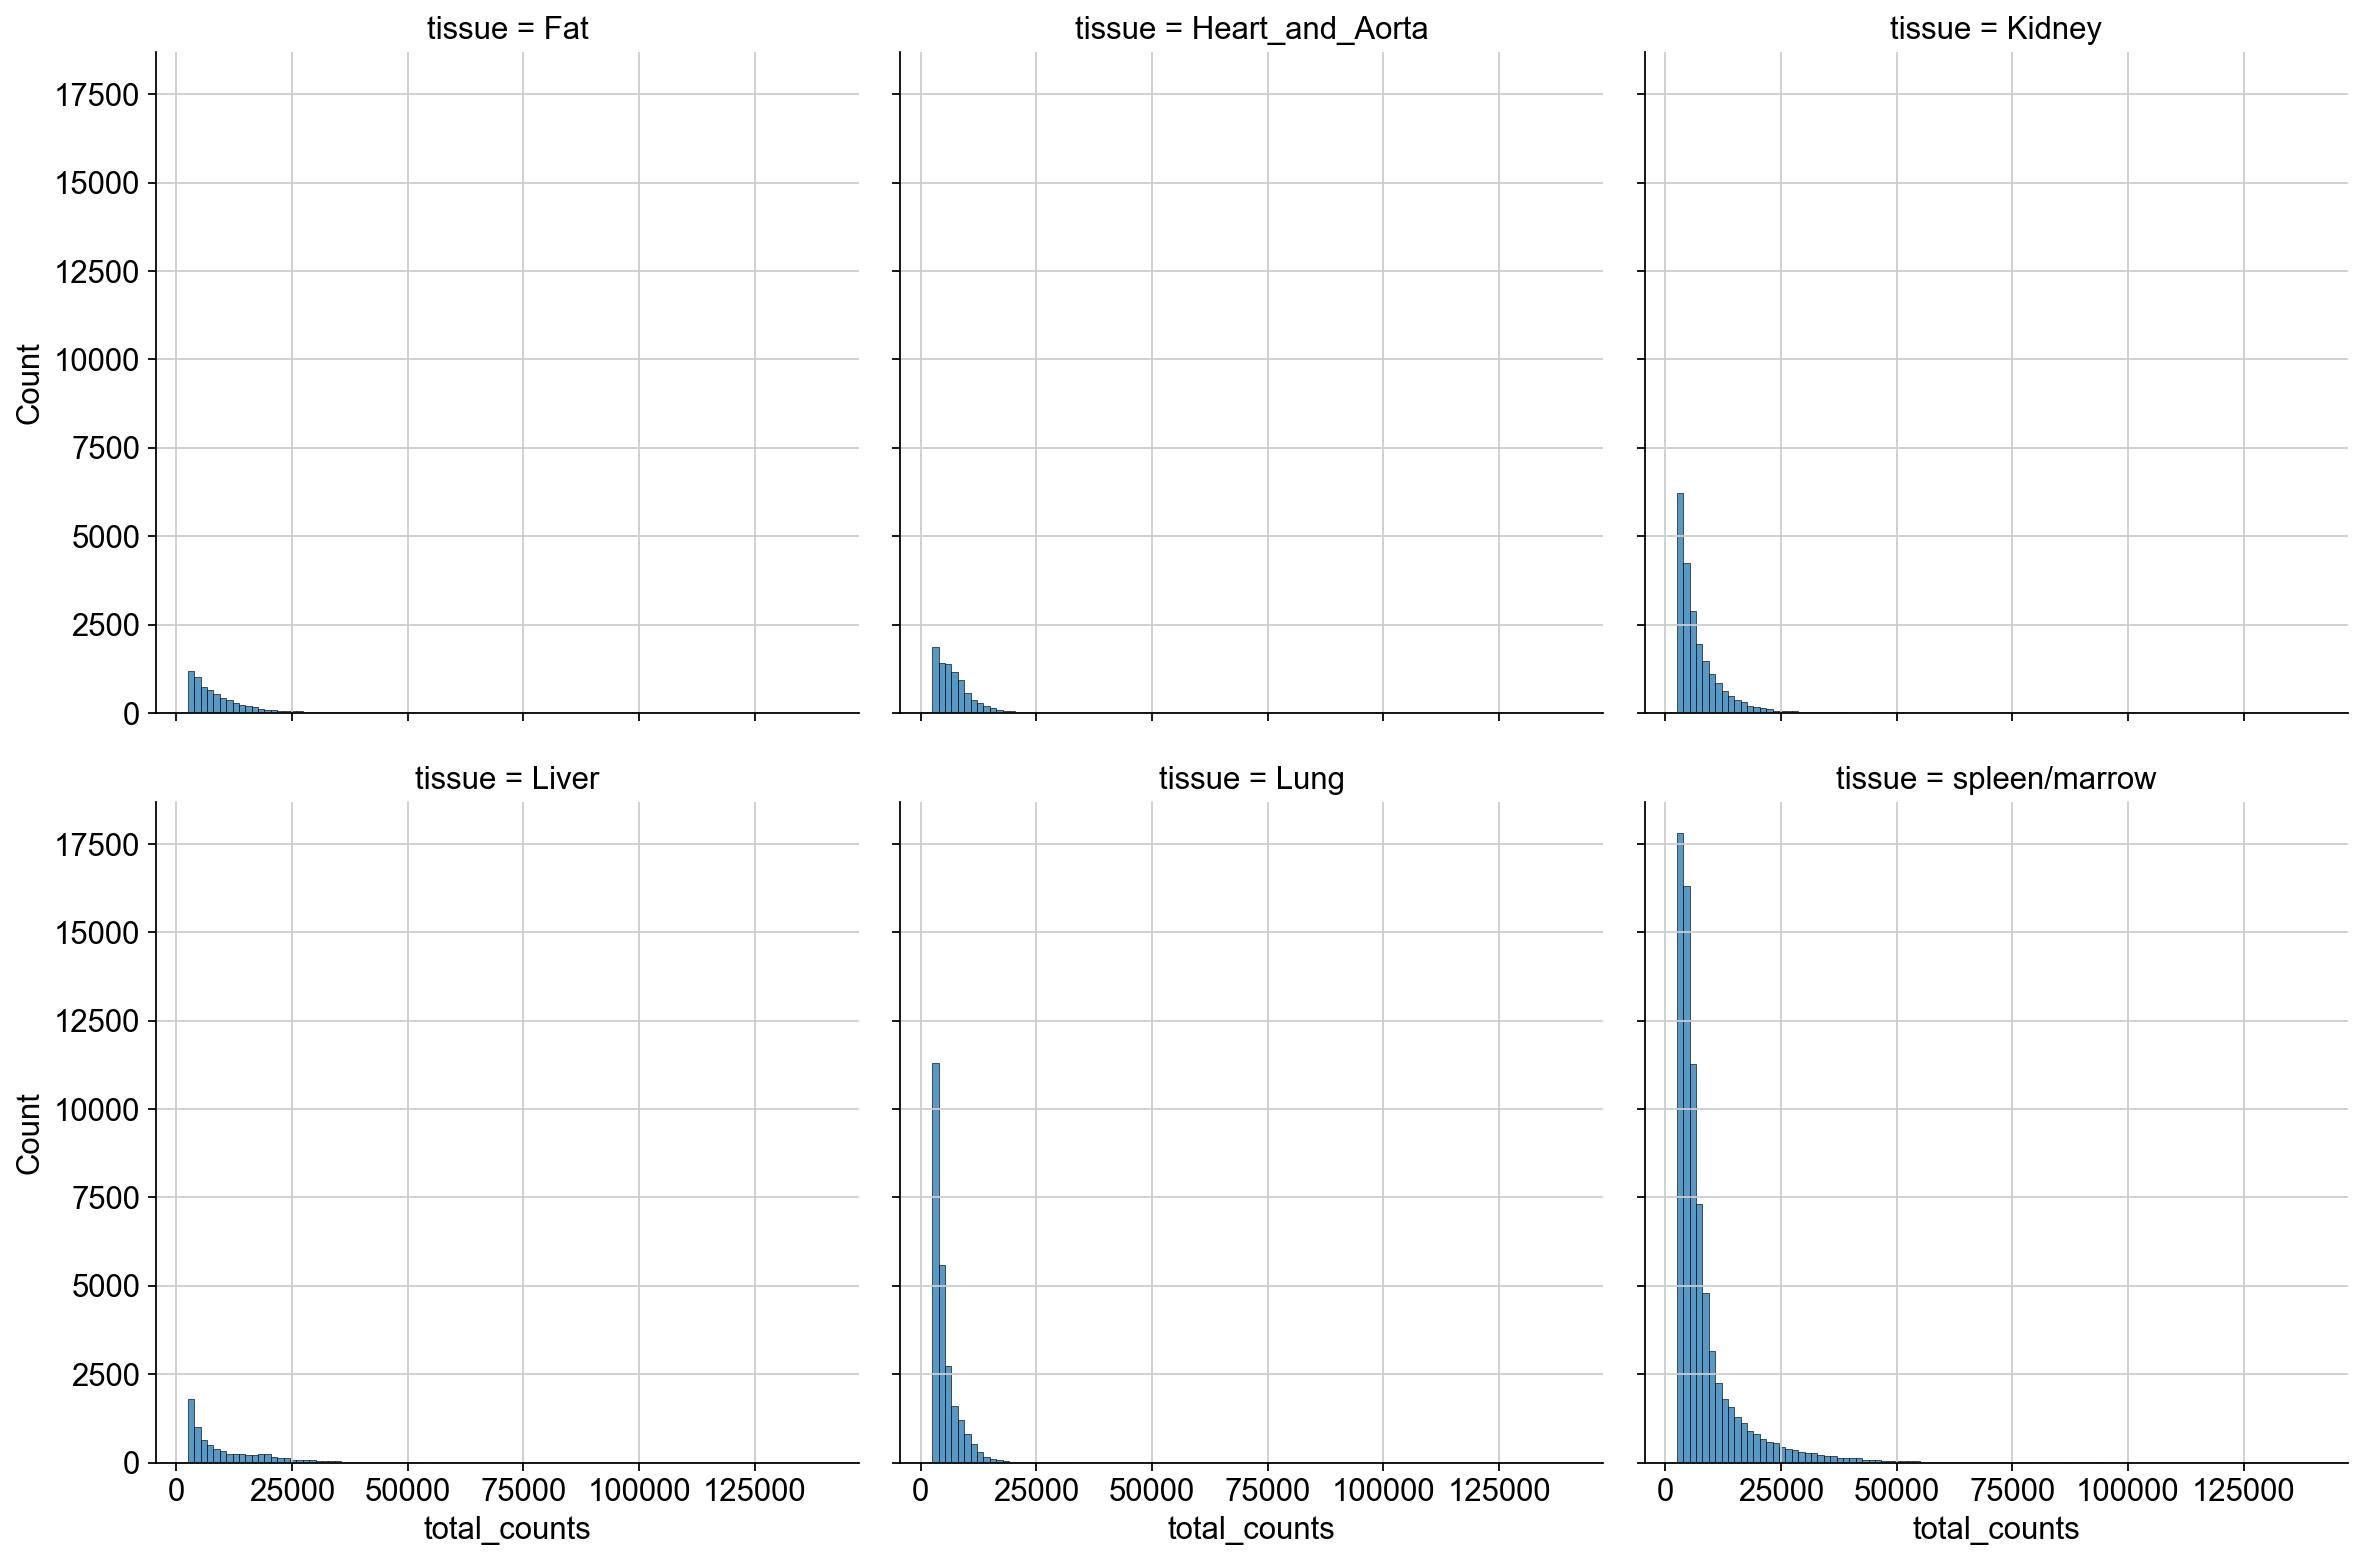

In [16]:
p1 = sns.displot(
    data=adata.obs, 
    x="n_genes_by_counts", 
    col="tissue",       # 使用 col 来按 tissue 分面，每个组织一张图
    col_wrap=3,         # 每行显示 3 张图
    bins=100, 
    kde=False
)
p2 = sns.displot(
    data=adata.obs, 
    x="total_counts", 
    col="tissue",       # 使用 col 来按 tissue 分面，每个组织一张图
    col_wrap=3,         # 每行显示 3 张图
    bins=100, 
    kde=False
)

In [17]:
adata = adata_filtered

In [18]:
pdf=PdfPages("../figures/qc/QC_by_tissue_mouse.pdf")

metrics=["n_genes_by_counts","total_counts","pct_counts_mt","pct_counts_ribo"]

for group in ["tissue","mouse"]:
    if group not in adata.obs.columns:
        continue
    for metric in metrics:
        plt.figure(figsize=(12,5))
        sns.violinplot(data=adata.obs,x=group,y=metric,cut=0)
        plt.xticks(rotation=90)
        plt.title(f"{metric} by {group}")
        plt.tight_layout()
        pdf.savefig()
        plt.close()

pdf.close()

In [19]:
adata.write_h5ad("../data_interim/filtered.h5ad")

In [20]:
rcb.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

In [21]:
%%R
library(Seurat)
library(scater)
library(scDblFinder)
library(SingleCellExperiment)
library(BiocParallel)

载入需要的程序包：SeuratObject
载入需要的程序包：sp

载入程序包：'SeuratObject'

The following objects are masked from 'package:base':

    intersect, t

载入需要的程序包：SingleCellExperiment
载入需要的程序包：SummarizedExperiment
载入需要的程序包：MatrixGenerics
载入需要的程序包：matrixStats

载入程序包：'MatrixGenerics'

The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, r

In [22]:
data_mat = adata.X.T

In [23]:
data_mat = adata.X.T.tocsc()

x = data_mat.data.astype(np.float64)
i = data_mat.indices.astype(np.int32)
p = data_mat.indptr.astype(np.int32)
dims = np.array(data_mat.shape, dtype=np.int32)

# 传递capture/sample信息给scDblFinder
samples = (
    adata.obs["tissue"].astype(str)
    + "_"
    + adata.obs["mouse.id"].astype(str)
).values

with localconverter(ro.default_converter + numpy2ri.converter):
    ro.globalenv["x"] = x
    ro.globalenv["i"] = i
    ro.globalenv["p"] = p
    ro.globalenv["dims"] = dims
    ro.globalenv["samples"] = samples

In [24]:
%%R -o doublet_score -o doublet_class

x <- as.numeric(x)
i <- as.integer(i)
p <- as.integer(p)
dims <- as.integer(dims)

data_mat <- new("dgCMatrix", Dim = dims, x = x, i = i, p = p)

set.seed(123)

sce <- scDblFinder(
    SingleCellExperiment(list(counts = data_mat)),
    samples = samples
)

doublet_score <- sce$scDblFinder.score
doublet_class <- sce$scDblFinder.class

  |======================================================================| 100%



In addition: Warning messages:
1: In scDblFinder(sce[sel_features, x], clusters = clusters, dims = dims,  :
  scDblFinder might not work well with very low numbers of cells.
2: In scDblFinder(sce[sel_features, x], clusters = clusters, dims = dims,  :
  scDblFinder might not work well with very low numbers of cells.
3: In scDblFinder(sce[sel_features, x], clusters = clusters, dims = dims,  :
  scDblFinder might not work well with very low numbers of cells.


In [25]:
adata.obs["scDblFinder_score"] = doublet_score
adata.obs["scDblFinder_class"] = doublet_class
adata.obs.scDblFinder_class.value_counts()
adata.write("../data_interim/filtered_doublet.h5ad")
del data_mat

In [7]:
rcb.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

In [2]:
adata = ad.read_h5ad("../data_interim/filtered_doublet.h5ad")

In [3]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [4]:
# Normalizing to median total counts
sc.pp.normalize_total(adata,target_sum=1e4)
# Logarithmize the data
sc.pp.log1p(adata)

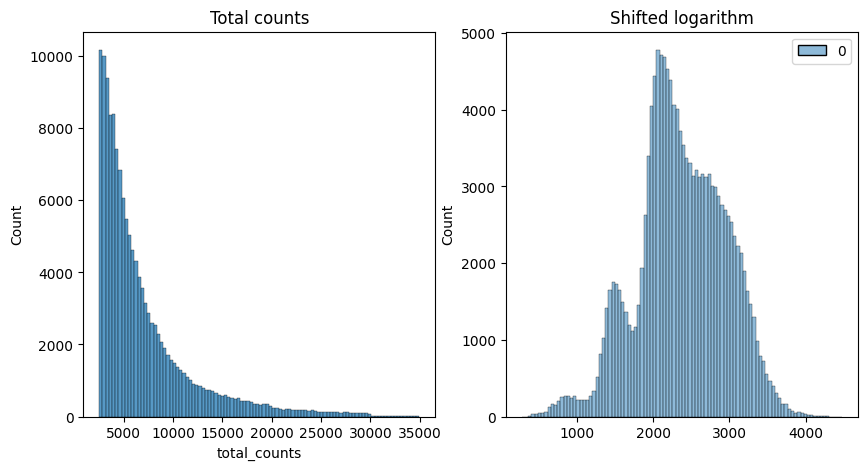

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.X.sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

In [6]:
adata.write("../data_interim/normalized.h5ad")

In [7]:
sc.pp.highly_variable_genes(adata,layer="counts",flavor="seurat_v3",n_top_genes=3000)

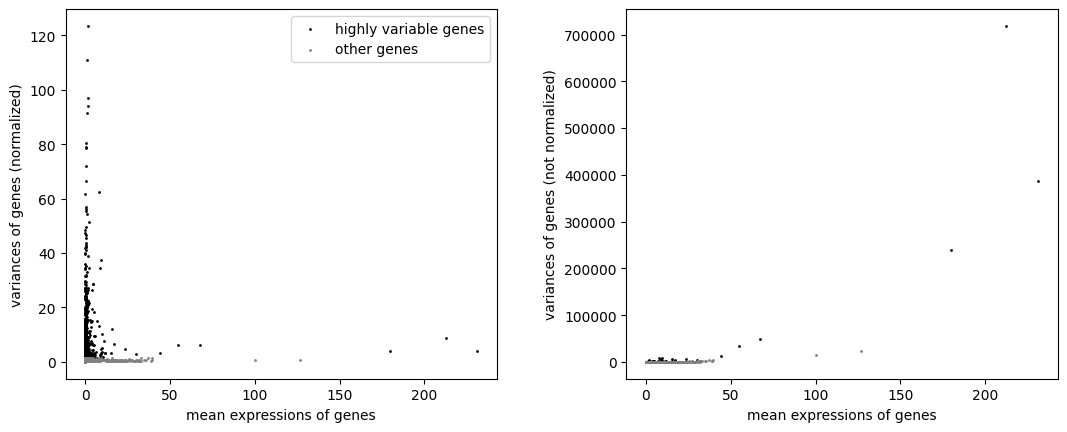

In [9]:
sc.pl.highly_variable_genes(adata)

In [8]:
adata.var["highly_variable"].value_counts()

highly_variable
False    17138
True      3000
Name: count, dtype: int64

In [15]:
adata.write("../data_interim/feature_selection.h5ad")

In [2]:
adata = ad.read_h5ad("../data_interim/feature_selection.h5ad")

In [3]:
sc.tl.pca(adata,n_comps=50,svd_solver='arpack',mask_var='highly_variable')

C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_19012\2332710144.py:1: FutureWarning: The function pca_scatter is deprecated and will be removed in the future. Use :func:`scanpy.pl.pca` instead.
  sc.pl.pca_scatter(adata, color="cell_ontology_class")


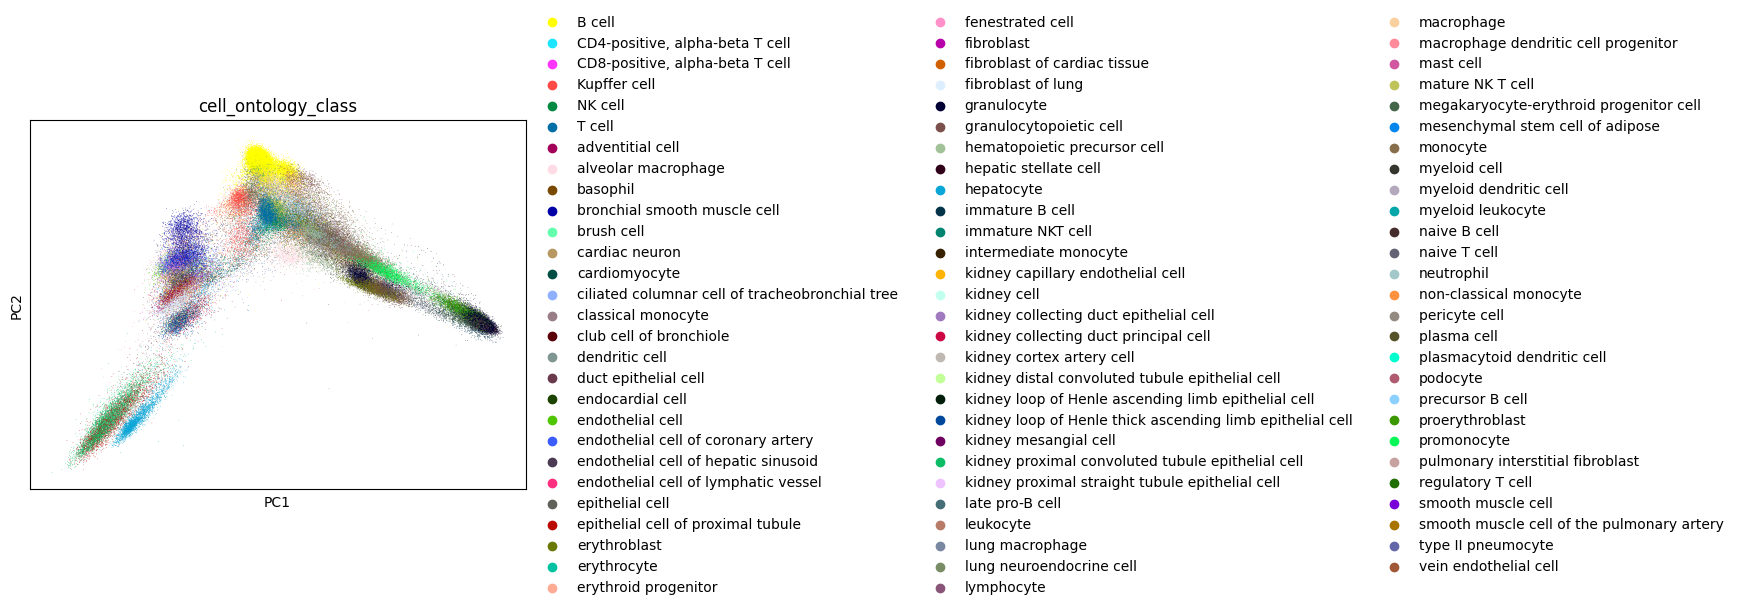

In [4]:
sc.pl.pca_scatter(adata, color="cell_ontology_class")

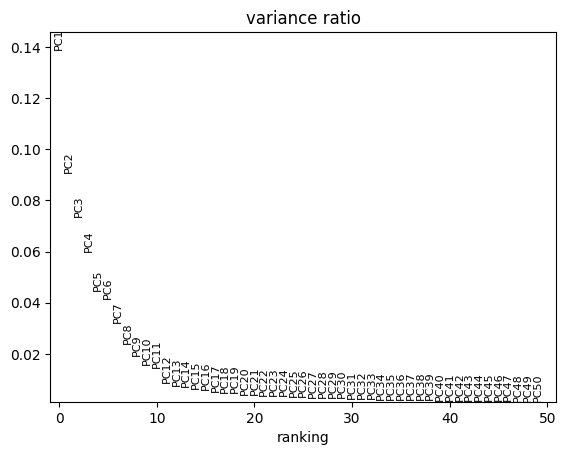

In [5]:
sc.pl.pca_variance_ratio(adata, n_pcs=50)

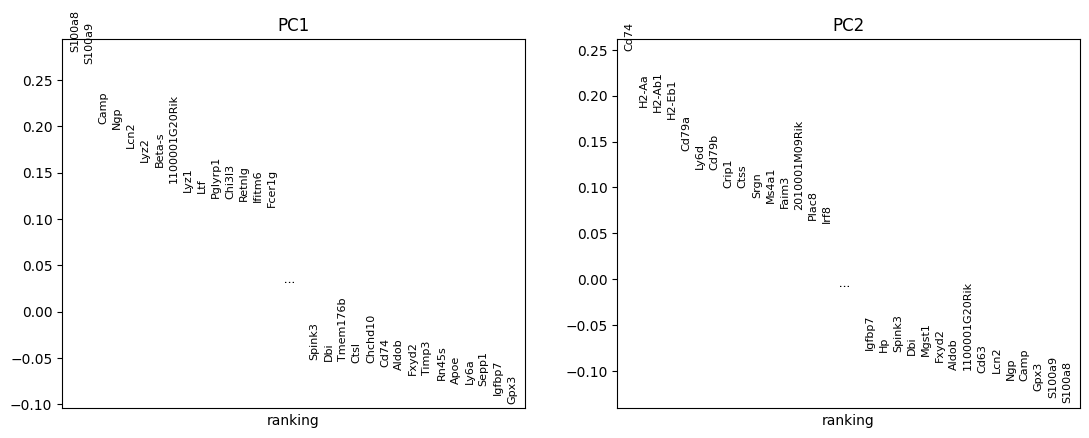

In [6]:
sc.pl.pca_loadings(adata, components=(1, 2), include_lowest=True)

In [7]:
sc.pp.neighbors(adata, n_neighbors=30,n_pcs=20,random_state=2026)

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
adata.write_h5ad("../data_interim/after_neighbored.h5ad")

In [2]:
adata = ad.read_h5ad("../data_interim/after_neighbored.h5ad")

In [3]:
sc.tl.leiden(adata,resolution=0.5,random_state=0,flavor="igraph",n_iterations=2,directed=False)
adata.obs["leiden"] = adata.obs["leiden"].copy()
adata.uns["leiden"] = adata.uns["leiden"].copy()
adata.obsm["X_umap"] = adata.obsm["X_umap"].copy()

In [4]:
sc.tl.paga(adata,groups="leiden")

In [5]:
sc.pl.paga(adata,plot=False)

In [6]:
sc.tl.umap(adata, min_dist=0.3,init_pos='paga')

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


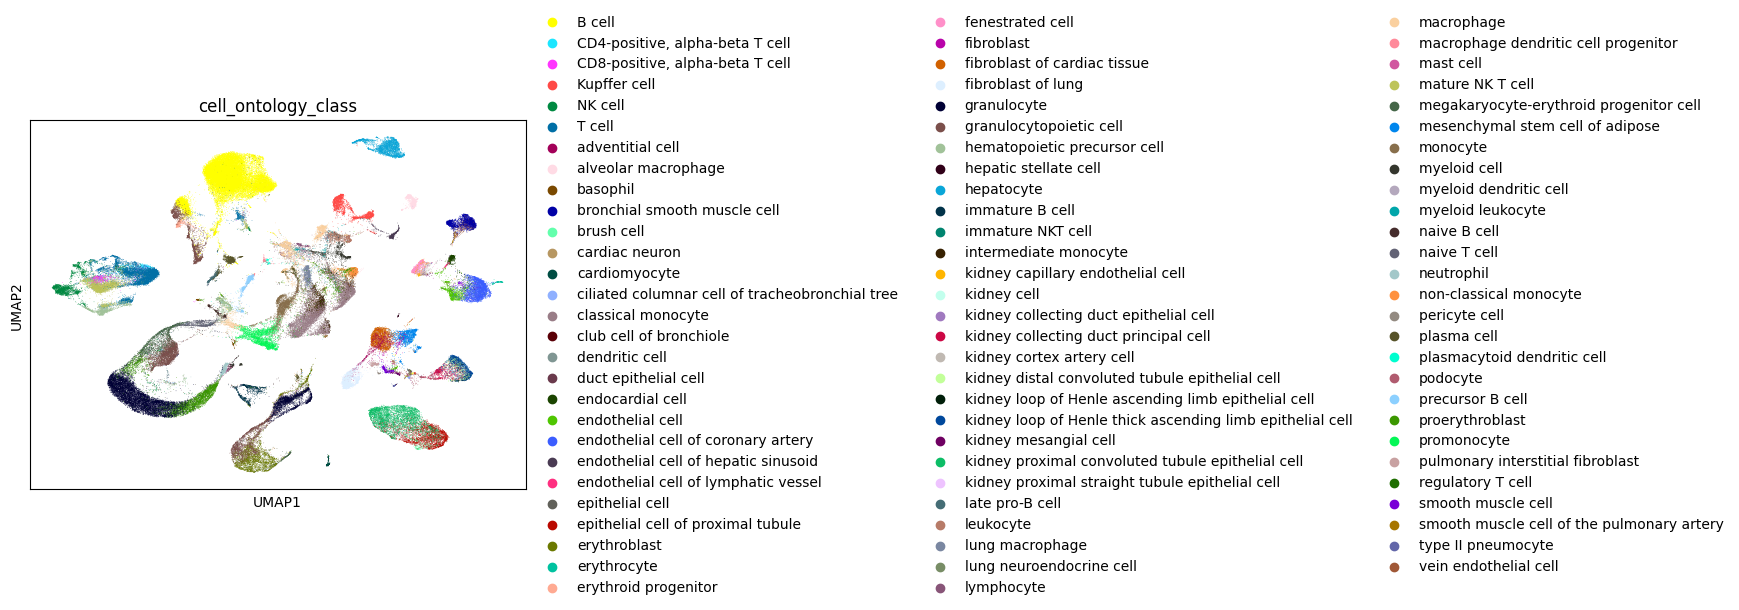

In [8]:
sc.pl.umap(adata,color='cell_ontology_class')

In [11]:
adata.write_h5ad("../data_interim/dimensionality_reduced.h5ad")